✅ SVM Accuracy: 96.26 %

📊 Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.95      0.96       278
           1       0.98      0.98      0.98       471
           2       0.56      1.00      0.72        19
           3       1.00      0.14      0.25         7

    accuracy                           0.96       775
   macro avg       0.88      0.77      0.73       775
weighted avg       0.97      0.96      0.96       775

📉 Confusion Matrix:
 [[263   9   6   0]
 [  5 463   3   0]
 [  0   0  19   0]
 [  0   0   6   1]]


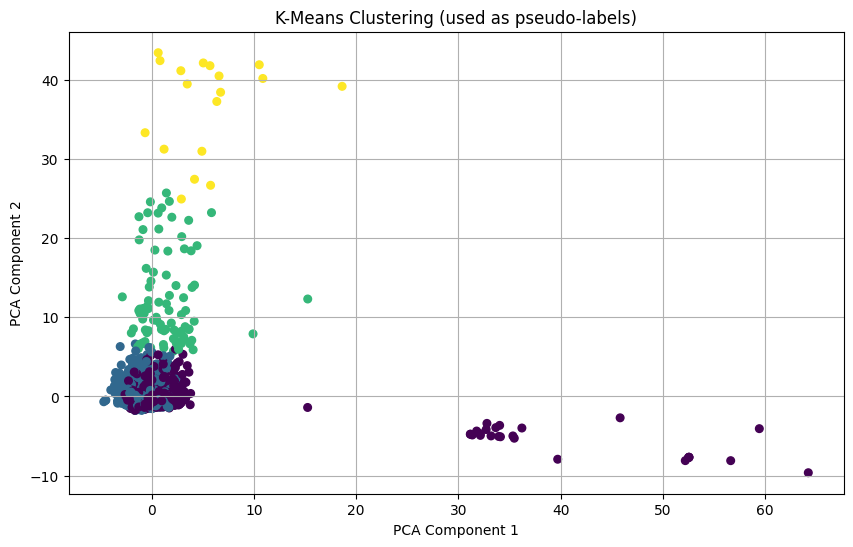

In [ ]:
# Step 1: Import libraries
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt

# Step 2: Load dataset
file_path = "/content/language marker.csv"  # Change path if local
df = pd.read_csv(file_path)

# Step 3: Select numeric columns only (drop IDs and non-numeric info)
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Step 4: Scale the numeric features
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_df)

# Step 5: Generate pseudo-labels using KMeans
kmeans = KMeans(n_clusters=4, random_state=42)
pseudo_labels = kmeans.fit_predict(scaled_data)
df['Cluster'] = pseudo_labels  # Add to original dataframe

# Step 6: Train/Test split for SVM using pseudo-labels
X = scaled_data
y = df['Cluster']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 7: Train the SVM classifier
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train, y_train)

# Step 8: Predict and evaluate
y_pred = svm_model.predict(X_test)

# Accuracy and evaluation report
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print("✅ SVM Accuracy:", round(accuracy * 100, 2), "%")
print("\n📊 Classification Report:\n", report)
print("📉 Confusion Matrix:\n", conf_matrix)

# Step 9: Optional - Visualize clusters using PCA
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)
plt.figure(figsize=(10, 6))
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=pseudo_labels, cmap='viridis', s=30)
plt.title("K-Means Clustering (used as pseudo-labels)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.show()


In [ ]:
# Step 1: Import libraries
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Load dataset
df = pd.read_csv("/content/language marker.csv")

# Step 2: Select numeric features
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Step 3: Scale features
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_df)

# Step 4: KMeans clustering to get pseudo-labels
kmeans = KMeans(n_clusters=4, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_data)

# Step 5: Map clusters to actual categories
# Based on earlier inspection of average scores in each cluster
cluster_to_category = {
    1: "Non-Demented",
    3: "Mild Dementia",
    0: "Moderate Dementia",
    2: "Severe Dementia"
}
df['Assigned_Label'] = df['Cluster'].map(cluster_to_category)

# Step 6: Show category distribution
print("🧠 Dementia Categories Assigned:\n")
print(df['Assigned_Label'].value_counts())

# Optional: Save to CSV
df.to_csv("language_marker_with_categories.csv", index=False)


🧠 Dementia Categories Assigned:

Assigned_Label
Non-Demented         2367
Moderate Dementia    1401
Severe Dementia        87
Mild Dementia          18
Name: count, dtype: int64


In [ ]:
# ============================================================
# Language Marker SVM Model (Train + CCNA Validation)
# ============================================================

import pandas as pd
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# ------------------------------------------------------------
# Choose mode
# ------------------------------------------------------------
mode = "validate"   # change to "validate" later

# ------------------------------------------------------------
# Training Mode
# ------------------------------------------------------------
if mode == "train":
    # Load dataset (ADNI/UPENN language markers)
    df = pd.read_csv("/content/language marker.csv")

    # Select numeric columns only (drop IDs and non-numeric)
    numeric_df = df.select_dtypes(include=["int64","float64"])

    # Scale features
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(numeric_df)

    # Pseudo-labels via clustering
    kmeans = KMeans(n_clusters=4, random_state=42)
    pseudo_labels = kmeans.fit_predict(scaled_data)
    df["Cluster"] = pseudo_labels

    # Train/test split
    X = scaled_data
    y = df["Cluster"]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Train SVM
    svm_model = SVC(kernel="rbf", probability=True, random_state=42)
    svm_model.fit(X_train, y_train)

    # Evaluate
    y_pred = svm_model.predict(X_test)
    print("✅ SVM Accuracy:", round(accuracy_score(y_test, y_pred)*100,2), "%")
    print("\n📊 Classification Report:\n", classification_report(y_test, y_pred))
    print("📉 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

    # Save model, scaler, feature list
    joblib.dump(svm_model, "lang_svm_model.pkl")
    joblib.dump(scaler, "lang_scaler.pkl")
    joblib.dump(numeric_df.columns.tolist(), "lang_features.pkl")

    print("✅ Model, scaler, and features saved!")

# ------------------------------------------------------------
# Validation Mode
# ------------------------------------------------------------
elif mode == "validate":
    # Load CCNA LANGUAGE MARKER dataset
    ccna = pd.read_csv("/content/LANGUAGE MARKER.csv")

    # Keep only numeric features
    numeric_ccna = ccna.select_dtypes(include=["int64","float64"])

    # Load saved model, scaler, features
    svm_model = joblib.load("lang_svm_model.pkl")
    scaler = joblib.load("lang_scaler.pkl")
    train_features = joblib.load("lang_features.pkl")

    # Align CCNA features with training
    X_ccna = numeric_ccna.reindex(columns=train_features, fill_value=0)

    # Scale
    X_ccna_scaled = scaler.transform(X_ccna)

    # Predict
    y_pred = svm_model.predict(X_ccna_scaled)

    # Save predictions
    out = pd.DataFrame({
        "ID": ccna["Identifiers"],
        "langmarker_pred": y_pred
    })
    out.to_csv("langmarker_svm_preds.csv", index=False)

    print("✅ CCNA language predictions saved to langmarker_svm_preds.csv")


✅ CCNA language predictions saved to langmarker_svm_preds.csv
